<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 134 · Forecasting Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: From Forecast to Decision</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">Turn a forecast into an order. Compare two forecasts with the accuracy panel and a Diebold-Mariano test, then use the newsvendor model to convert the winner and its uncertainty into a cost-optimal order quantity, a quantile of demand set by the cost of a stockout versus a leftover, backtested on cost and service level.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Case Study: From Forecast to Decision
A forecast is not the answer, it is an input to a **decision**: how many units to order tonight. And the best order is almost never the forecast itself, because being **short** and being **over** cost different amounts. This case study compares two forecasts honestly (accuracy panel plus a Diebold-Mariano test), then turns the winner into an order quantity with the **newsvendor** model, where the optimal order is a **quantile** of demand set by the cost ratio, not the average.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings; warnings.filterwarnings('ignore')
def mape(a,f): return float(np.mean(np.abs((a.values-np.asarray(f))/a.values))*100)
def mae(a,f): return float(np.mean(np.abs(a.values-np.asarray(f))))
def rmse(a,f): return float(np.sqrt(np.mean((a.values-np.asarray(f))**2)))

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The decision and its costs</div>
<div style="color:#4a5578;margin-top:6px">Order too few, lose a sale; too many, waste stock.</div>
</div>

A store orders a perishable product once a day. If it <strong>runs short</strong>, it loses the margin on each missed sale, the <strong>underage cost</strong>, here about <strong>$8 per unit</strong>. If it <strong>over-orders</strong>, leftover units are wasted, the <strong>overage cost</strong>, about <strong>$2 per unit</strong>. These are <strong>asymmetric</strong>: a stockout hurts four times as much as a leftover. Success is <strong>minimum total cost</strong>, not minimum forecast error.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 &#183; COLLECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two years of daily demand</div>
<div style="color:#4a5578;margin-top:6px">One value per day.</div>
</div>

In [3]:
try: raw = pd.read_excel('../../data/ch134_product_demand.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'ch134_product_demand.xlsx', sheet_name='Data')
raw['date']=pd.to_datetime(raw['date']); s = raw.set_index('date')['demand'].asfreq('D')
print('days:', len(s), '| mean %.0f, std %.0f units/day' % (s.mean(), s.std()))

days: 731 | mean 220, std 39 units/day


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A weekly rhythm with real scatter</div>
<div style="color:#4a5578;margin-top:6px">The day-to-day noise is the whole point.</div>
</div>

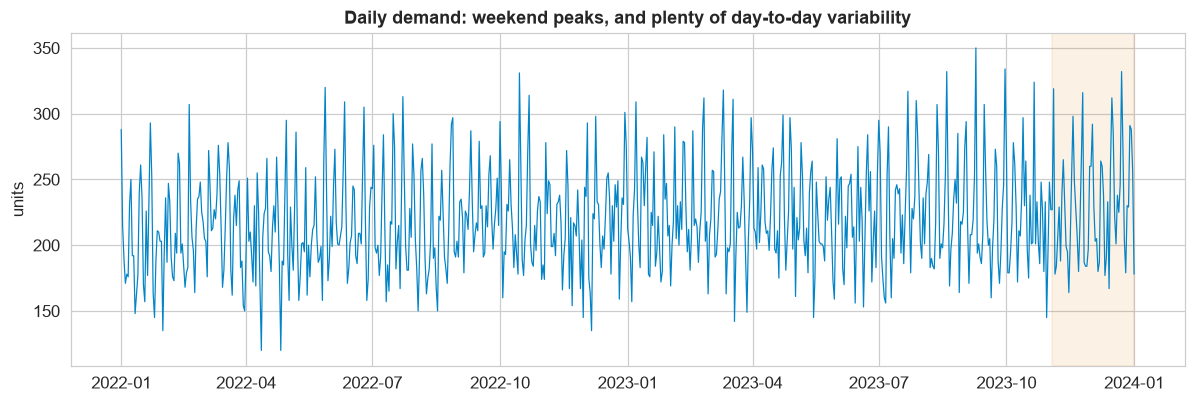

weekend avg 250 vs weekday avg 207 units


In [4]:
H=60; train, test = s[:-H], s[-H:]
fig,ax=plt.subplots(figsize=(11,3.8)); ax.plot(s.index, s.values, color=EM, lw=0.8)
ax.axvspan(test.index[0], test.index[-1], color=AMBER, alpha=0.10); ax.set(title='Daily demand: weekend peaks, and plenty of day-to-day variability', ylabel='units')
plt.tight_layout(); plt.show()
print('weekend avg %d vs weekday avg %d units' % (s[s.index.dayofweek>=5].mean(), s[s.index.dayofweek<5].mean()))

Demand peaks on weekends and carries a slow trend, but the star of this chapter is the <strong>scatter</strong>: even a perfect forecast of the average leaves real day-to-day variability. That uncertainty is exactly what the order decision must hedge against.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 4 &#183; FORECAST</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit two competing models</div>
<div style="color:#4a5578;margin-top:6px">A weak one and a strong one.</div>
</div>

In [5]:
snaive = np.array([train.iloc[-7 + (i % 7)] for i in range(H)])   # repeat last week
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
hw_fc = hw.forecast(H).values
print('two forecasts produced for the 60-day holdout: seasonal-naive and Holt-Winters')

two forecasts produced for the 60-day holdout: seasonal-naive and Holt-Winters


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 5 &#183; COMPARE ACCURACY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Grade them on the holdout</div>
<div style="color:#4a5578;margin-top:6px">The full panel.</div>
</div>

In [6]:
rows=[]
for name,f in [('seasonal-naive',snaive),('Holt-Winters',hw_fc)]:
    rows.append({'model':name,'MAE':round(mae(test,f),1),'RMSE':round(rmse(test,f),1),'MAPE_%':round(mape(test,f),2)})
print(pd.DataFrame(rows).to_string(index=False))

         model  MAE  RMSE  MAPE_%
seasonal-naive 44.1  58.8   18.64
  Holt-Winters 20.0  25.1    9.04


On the held-out 60 days, <strong>Holt-Winters</strong> is clearly more accurate, about <strong>9% MAPE</strong> versus <strong>19%</strong> for seasonal-naive. But a ranking is only trustworthy if the gap is real, so we test it.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 6 &#183; TEST THE DIFFERENCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Diebold-Mariano</div>
<div style="color:#4a5578;margin-top:6px">Is Holt-Winters really better, or lucky?</div>
</div>

In [7]:
def dm(a,f1,f2):
    d=(a-f1)**2-(a-f2)**2; n=len(d); dbar=d.mean(); var=np.mean((d-dbar)**2)
    stat=dbar/np.sqrt(var/n); return stat, 2*(1-stats.norm.cdf(abs(stat)))
st, p = dm(test.values, snaive, hw_fc)
print('Diebold-Mariano (seasonal-naive vs Holt-Winters): stat %.2f, p = %.4f' % (st, p))
print('p < 0.05 and stat > 0 -> Holt-Winters is SIGNIFICANTLY more accurate. We use it.')

Diebold-Mariano (seasonal-naive vs Holt-Winters): stat 4.34, p = 0.0000
p < 0.05 and stat > 0 -> Holt-Winters is SIGNIFICANTLY more accurate. We use it.


The <strong>Diebold-Mariano test</strong> confirms the difference is <strong>statistically significant</strong> (p well below 0.05), not a fluke of one holdout. Holt-Winters wins, so it feeds the decision. Now the real work begins.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 7 &#183; QUANTIFY UNCERTAINTY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The forecast is a guess, not a fact</div>
<div style="color:#4a5578;margin-top:6px">Demand scatters around it.</div>
</div>

In [8]:
resid_sd = float(np.std(train.values - hw.fittedvalues.values))
print('Holt-Winters point forecast is a best guess; actual demand scatters around it.')
print('one-step forecast error std ~ %.1f units -> that spread is what the order must cover' % resid_sd)

Holt-Winters point forecast is a best guess; actual demand scatters around it.
one-step forecast error std ~ 26.6 units -> that spread is what the order must cover


The point forecast is the <strong>middle</strong> of a distribution of possible demand, not a certainty. Its spread (an error standard deviation of about <strong>27 units</strong>) is the uncertainty the order has to hedge. If both errors cost the same, you would order the middle; because they do not, you should not.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 8 &#183; THE DECISION MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Newsvendor: order a quantile, not the mean</div>
<div style="color:#4a5578;margin-top:6px">The critical fractile sets which one.</div>
</div>

In [9]:
Cu, Co = 8.0, 2.0                                  # underage (stockout) and overage (waste), $/unit
fractile = Cu / (Cu + Co)
z = stats.norm.ppf(fractile)
print('critical fractile = Cu / (Cu + Co) = %.0f / %.0f = %.2f' % (Cu, Cu+Co, fractile))
print('order to the %.0fth percentile of demand (z = %.2f), NOT the 50th (the mean)' % (fractile*100, z))
print('because a stockout costs %.0fx a leftover, carry a buffer ABOVE the forecast' % (Cu/Co))

critical fractile = Cu / (Cu + Co) = 8 / 10 = 0.80
order to the 80th percentile of demand (z = 0.84), NOT the 50th (the mean)
because a stockout costs 4x a leftover, carry a buffer ABOVE the forecast


The <strong>newsvendor model</strong> gives the answer in one line: the cost-minimizing order is the <strong>critical fractile</strong> quantile of demand, where the fractile is <code>Cu / (Cu + Co)</code>. Here that is <strong>0.80</strong>, order to the <strong>80th percentile</strong>, well above the average. The intuition is simple: when running short is four times as expensive as overstocking, you deliberately carry a safety buffer.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 9 &#183; POINT FORECAST vs OPTIMAL ORDER</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The cost of ordering the average</div>
<div style="color:#4a5578;margin-top:6px">There is a clear minimum, and it is not at 0.5.</div>
</div>

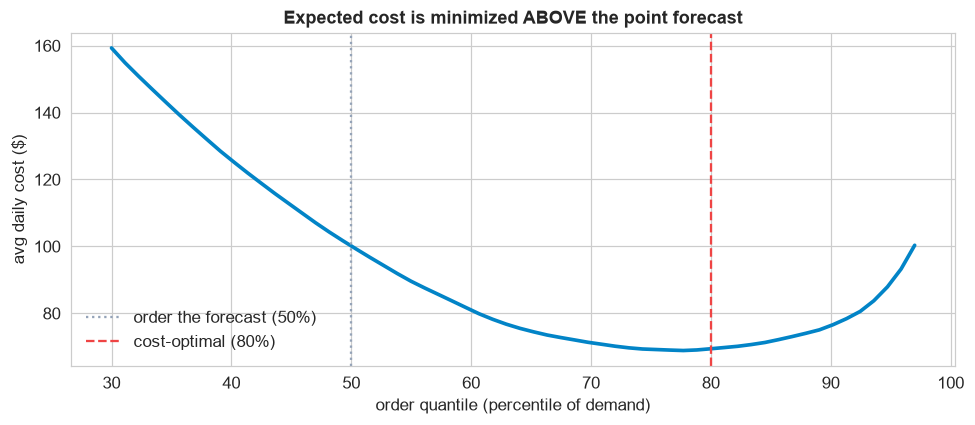

empirical cost-minimizing fractile on the holdout: 78% (theory said 80%)


In [10]:
q_point = hw_fc                                    # order the point forecast (50th percentile)
q_star  = hw_fc + z * resid_sd                     # order the 80th percentile
def cost(demand, order): return Cu*np.maximum(demand-order,0) + Co*np.maximum(order-demand,0)
fr = np.linspace(0.30, 0.97, 60); avg_cost=[cost(test.values, hw_fc + stats.norm.ppf(q)*resid_sd).mean() for q in fr]
best = fr[int(np.argmin(avg_cost))]
fig,ax=plt.subplots(figsize=(9,4)); ax.plot(fr*100, avg_cost, color=EM, lw=2.4)
ax.axvline(50, color=GREY, ls=':', label='order the forecast (50%)'); ax.axvline(fractile*100, color=RED, ls='--', label='cost-optimal (%.0f%%)'%(fractile*100))
ax.set(xlabel='order quantile (percentile of demand)', ylabel='avg daily cost ($)', title='Expected cost is minimized ABOVE the point forecast'); ax.legend(); plt.tight_layout(); plt.show()
print('empirical cost-minimizing fractile on the holdout: %.0f%% (theory said %.0f%%)' % (best*100, fractile*100))

Sweeping the order across quantiles traces a clear cost curve, and its <strong>minimum sits near the 80th percentile</strong>, exactly where the newsvendor formula predicted, not at the 50th where the point forecast lives. Ordering the average is a common, expensive mistake; the cost curve shows why.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 10 &#183; BACKTEST THE DECISION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Total cost and service level</div>
<div style="color:#4a5578;margin-top:6px">Two orders, one holdout.</div>
</div>

order = point forecast : $100/day  |  service level 47% (days demand fully met)
order = 80% fractile   : $69/day  |  service level 83%
the quantile order is 31% cheaper AND meets demand far more often


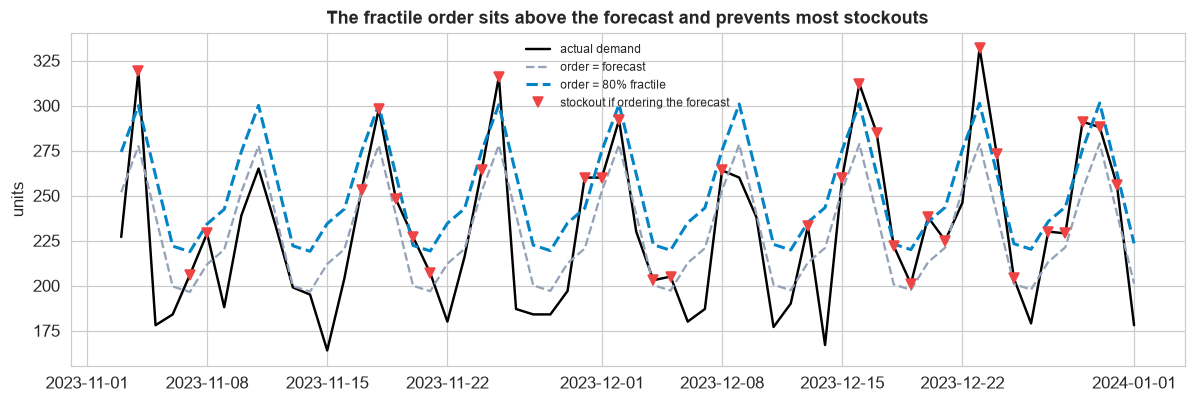

In [11]:
c_point = cost(test.values, q_point).mean(); c_star = cost(test.values, q_star).mean()
print('order = point forecast : $%.0f/day  |  service level %.0f%% (days demand fully met)' % (c_point, 100*np.mean(test.values<=q_point)))
print('order = 80%% fractile   : $%.0f/day  |  service level %.0f%%' % (c_star, 100*np.mean(test.values<=q_star)))
print('the quantile order is %.0f%% cheaper AND meets demand far more often' % (100*(c_point-c_star)/c_point))
fig,ax=plt.subplots(figsize=(11,3.8)); ax.plot(test.index, test.values, color='k', lw=1.6, label='actual demand')
ax.plot(test.index, q_point, '--', color=GREY, label='order = forecast'); ax.plot(test.index, q_star, '--', color=EM, lw=2, label='order = 80% fractile')
sh = test.values > q_point; ax.plot(test.index[sh], test.values[sh], 'v', color=RED, ms=6, label='stockout if ordering the forecast')
ax.set(title='The fractile order sits above the forecast and prevents most stockouts', ylabel='units'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

Backtested over the holdout, ordering the point forecast leaves the shelf empty on more than <strong>half</strong> the days (service level about 47%) and costs about <strong>$100/day</strong>. The 80th-percentile order lifts service to about <strong>83%</strong> and cuts cost to about <strong>$69/day</strong>, roughly <strong>31% cheaper</strong>. The red markers are the stockouts the buffer prevents. Better <em>decisions</em>, from the same forecast.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 11 &#183; DEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A one-line order rule on new data</div>
<div style="color:#4a5578;margin-top:6px">Forecast in, order out.</div>
</div>

In [12]:
def order_quantity(point_forecast, error_sd, Cu, Co):
    z = stats.norm.ppf(Cu/(Cu+Co)); return point_forecast + z*error_sd
final = ExponentialSmoothing(s, trend='add', seasonal='add', seasonal_periods=7).fit()
tomorrow = float(final.forecast(1).iloc[0]); sd = float(np.std(s.values - final.fittedvalues.values))
q = order_quantity(tomorrow, sd, Cu, Co)
print('tomorrow: point forecast %.0f units | recommended ORDER %.0f units (a %.0f-unit safety buffer)' % (tomorrow, q, q-tomorrow))
print('expected: fully stocked ~80%% of such days, at the lowest long-run cost given the 4:1 cost ratio')

tomorrow: point forecast 198 units | recommended ORDER 220 units (a 22-unit safety buffer)


expected: fully stocked ~80%% of such days, at the lowest long-run cost given the 4:1 cost ratio


Deployment is a single rule: refit the forecast on all data, read tomorrow's point forecast and the error spread, and return the <strong>critical-fractile order</strong>. It reruns every evening. Change the cost ratio and the buffer changes automatically, which is exactly what you want when margins or waste costs shift.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the manager</div>
<div style="color:#4a5578;margin-top:6px">The order, and why it beats the forecast.</div>
</div>

<strong>For the store manager:</strong> our demand forecast is good (accurate to about 9%), but you should <strong>not</strong> order the forecast number. Because a stockout costs about four times a leftover, the cheapest policy is to order to the <strong>80th percentile</strong>, roughly <strong>22 units above</strong> the forecast. Doing so keeps the shelf stocked about <strong>83% of days</strong> instead of under half, and cuts total cost by about <strong>31%</strong>. Order the buffer, not the average, and we will revisit it if margins or waste costs change.

## From forecast to decision, in one view

1. **Define** the decision and its asymmetric costs (underage vs overage).
2-3. **Collect and inspect** the demand, noting its day-to-day scatter.
4-6. **Forecast** with competing models, **compare** accuracy, and **test** the gap with Diebold-Mariano.
7. **Quantify uncertainty**: the point forecast is the middle of a distribution.
8. **Decision model**: the newsvendor optimal order is the Cu/(Cu+Co) quantile of demand.
9-10. **Compare and backtest**: the quantile order beats ordering the average on cost and service.
11-12. **Deploy** a one-line order rule and **communicate** the buffer in plain English.

**The one idea to keep: the most accurate forecast is not the decision, the best order is a quantile of demand set by the cost of being wrong in each direction, so accuracy earns you a good forecast and the newsvendor formula turns it into a good decision.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>